# Data Speaks!! — BERT Fine-Tuning for IMDB Sentiment Classification

This notebook fine-tunes **`bert-base-uncased`** on the IMDB movie review dataset for binary sentiment classification (Positive (1) / Negative (0)).

### Pipeline Steps
| Step | Description |
|------|-------------|
| 0 | Environment & directory setup |
| 1 | Load & verify raw data (25K train + 25K test) |
| 2 | Data audit — nulls, duplicates, text stats, HTML artifacts |
| 3 | Text cleaning — HTML strip, whitespace normalize, dedup |
| 4 | Stratified train/validation split (90/10, seed=42) |
| 5 | BERT tokenization & PyTorch DataLoaders |
| 6 | BERT model training (3 epochs, GPU) & test-set evaluation |
| 7 | Export metrics CSV |

All artifacts are saved under **`bert/artifacts/`**.

---
## Step 0 — Environment & Directory Setup

In [1]:
import os
import sys
import time
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

# ── Reproducibility ────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# ── Paths (relative to this notebook inside bert/) ─────────────
DATA_DIR    = os.path.join("..", "processed")          # ../processed/
ARTIFACTS   = os.path.join(".", "artifacts")            # bert/artifacts/
MODELS_DIR  = os.path.join(ARTIFACTS, "models")
METRICS_DIR = os.path.join(ARTIFACTS, "metrics")
PLOTS_DIR   = os.path.join(ARTIFACTS, "plots")

for d in [ARTIFACTS, MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Device ─────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM    : {vram_gb:.1f} GB")
else:
    print("⚠  No GPU detected — training will be very slow on CPU.")
print(f"PyTorch : {torch.__version__}")
print("\n>>> Step 0 complete.")

c:\Users\dhanu\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device  : cuda
GPU     : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM    : 8.5 GB
PyTorch : 2.12.0.dev20260408+cu128


---
## Step 1 — Acquire and Verify Data

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "imdb_train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "imdb_test.csv"))

print(f"Train shape   : {train_df.shape}")
print(f"Test  shape   : {test_df.shape}")
print(f"Columns       : {list(train_df.columns)}")
print(f"\nTrain label counts:\n{train_df['label'].value_counts().to_string()}")
print(f"\nTest  label counts:\n{test_df['label'].value_counts().to_string()}")


Train shape   : (25000, 2)
Test  shape   : (25000, 2)
Columns       : ['text', 'label']

Train label counts:
label
1    12500
0    12500

Test  label counts:
label
1    12500
0    12500


---
## Step 2 — Data Audit (Read-Only)

In [3]:
#Null 
print("Counting null values")
print(f"Train nulls:\n{train_df.isnull().sum()}")
print(f"\nTest nulls:\n{test_df.isnull().sum()}")

#Duplicate
train_dups = train_df.duplicated(subset=["text"]).sum()
test_dups  = test_df.duplicated(subset=["text"]).sum()
print(f"\nCounting Duplicates")
print(f"Train: {train_dups}  |  Test: {test_dups}")

# Text length
train_len = train_df["text"].str.len()
test_len  = test_df["text"].str.len()
print(f"\nStatistics of character length")
print(f"Train : min={train_len.min()}, max={train_len.max()}, "
      f"mean={train_len.mean():.1f}, median={train_len.median():.1f}")
print(f"Test  : min={test_len.min()}, max={test_len.max()}, "
      f"mean={test_len.mean():.1f}, median={test_len.median():.1f}")

# HTML
html_train = train_df["text"].str.contains("<br", regex=False).sum()
html_test  = test_df["text"].str.contains("<br", regex=False).sum()
print(f"\nChecking html tags")
print(f"Train: {html_train} ({html_train/len(train_df):.1%})")
print(f"Test:  {html_test}  ({html_test/len(test_df):.1%})")

#Sample
raw_tokens = [
    tok for txt in train_df["text"].sample(2000, random_state=SEED)
    for tok in txt.split()
]
top20 = Counter(raw_tokens).most_common(20)
print(f"\nTop 20 most common")
for word, cnt in top20:
    print(f"  {word:<15} {cnt}")


Counting null values
Train nulls:
text     0
label    0
dtype: int64

Test nulls:
text     0
label    0
dtype: int64

Counting Duplicates
Train: 96  |  Test: 199

Statistics of character length
Train : min=52, max=13704, mean=1325.1, median=979.0
Test  : min=32, max=12988, mean=1293.8, median=962.0

Checking html tags
Train: 14665 (58.7%)
Test:  14535  (58.1%)

Top 20 most common
  the             23561
  a               12292
  and             12173
  of              11395
  to              10711
  is              8173
  in              6965
  I               5242
  that            5079
  this            4550
  it              4340
  /><br           4138
  was             3763
  with            3428
  as              3391
  for             3304
  The             2734
  but             2722
  movie           2461
  on              2401


---
## Step 3 — Clean the Text

In [4]:
def clean_text(text: str) -> str:
    """Strip HTML tags/entities, normalize whitespace."""
    text = html.unescape(text)                                    # decode &amp; etc.
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)  # <br /> → space
    text = re.sub(r"<[^>]+>", " ", text)                         # any remaining tags
    text = re.sub(r"\s+", " ", text).strip()                     # collapse whitespace
    return text

#       
train_df["text_clean"] = train_df["text"].apply(clean_text)
test_df["text_clean"]  = test_df["text"].apply(clean_text)

# Remove exact duplicates (keep first occurrence)
train_clean = (
    train_df.drop_duplicates(subset=["text_clean"], keep="first")
    .copy()[["text_clean", "label"]]
    .rename(columns={"text_clean": "text"})
)
test_clean = (
    test_df.drop_duplicates(subset=["text_clean"], keep="first")
    .copy()[["text_clean", "label"]]
    .rename(columns={"text_clean": "text"})
)

print(f"Train rows: {len(train_df)} → {len(train_clean)} (removed {len(train_df)-len(train_clean)} duplicates)")
print(f"Test  rows: {len(test_df)}  → {len(test_clean)}  (removed {len(test_df)-len(test_clean)} duplicates)")


# Save cleaned datasets
train_clean.to_csv(os.path.join(ARTIFACTS, "imdb_train_clean.csv"), index=False)
test_clean.to_csv(os.path.join(ARTIFACTS, "imdb_test_clean.csv"), index=False)
print(f"Saved cleaned CSVs to {ARTIFACTS}/")

Train rows: 25000 → 24902 (removed 98 duplicates)
Test  rows: 25000  → 24799  (removed 201 duplicates)
Saved cleaned CSVs to .\artifacts/


---
## Step 4 — Train / Validation Split

In [5]:
train_split, val_split = train_test_split(
    train_clean,
    test_size=0.10,
    random_state=SEED,
    stratify=train_clean["label"],
)

print(f"Train subset : {len(train_split):>6}  ({len(train_split)/len(train_clean):.1%})")
print(f"Val   subset : {len(val_split):>6}  ({len(val_split)/len(train_clean):.1%})")
print(f"Test  (held) : {len(test_clean):>6}")

print(f"\nTrain label balance:\n{train_split['label'].value_counts(normalize=True).to_string()}")
print(f"\nVal   label balance:\n{val_split['label'].value_counts(normalize=True).to_string()}")


Train subset :  22411  (90.0%)
Val   subset :   2491  (10.0%)
Test  (held) :  24799

Train label balance:
label
1    0.500781
0    0.499219

Val   label balance:
label
1    0.501004
0    0.498996


---
## Step 5 — BERT Tokenization & DataLoaders

In [6]:
MODEL_NAME = "bert-base-uncased"
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)


class IMDBDataset(Dataset):
    """PyTorch Dataset that tokenizes on-the-fly."""

    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


BATCH_SIZE = 16

train_ds = IMDBDataset(train_split["text"].values, train_split["label"].values, tokenizer)
val_ds   = IMDBDataset(val_split["text"].values,   val_split["label"].values,   tokenizer)
test_ds  = IMDBDataset(test_clean["text"].values,  test_clean["label"].values,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Tokenizer vocab : {tokenizer.vocab_size}")
print(f"Dataset sizes   : train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Batches         : train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

Tokenizer vocab : 30522
Dataset sizes   : train=22411, val=2491, test=24799
Batch size      : 16
Batches         : train=1401, val=156, test=1550


---
## Step 6 — Train BERT (3 Epochs, Mixed Precision)

In [7]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

EPOCHS      = 3
LR          = 2e-5
total_steps = len(train_loader) * EPOCHS

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps,
)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"Training {MODEL_NAME} for {EPOCHS} epochs on {device}…")
print(f"Total optimiser steps: {total_steps}")
t0 = time.time()

for epoch in range(EPOCHS):
    t_epoch = time.time()

    # Training
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, 1):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            out  = model(ids, attention_mask=mask, labels=lbls)
            loss = out.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item()

        if step % 300 == 0 or step == len(train_loader):
            print(f"  Epoch {epoch+1}/{EPOCHS}  step {step}/{len(train_loader)}  "
                  f"batch_loss={loss.item():.4f}")

    avg_train = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss_sum = 0.0
    vp, vt = [], []

    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbls = batch["labels"].to(device)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                out = model(ids, attention_mask=mask, labels=lbls)

            val_loss_sum += out.loss.item()
            vp.extend(torch.argmax(out.logits, 1).cpu().numpy())
            vt.extend(lbls.cpu().numpy())

    avg_val = val_loss_sum / len(val_loader)
    v_acc   = accuracy_score(vt, vp)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc"].append(v_acc)

    dt = time.time() - t_epoch
    print(f"  ── Epoch {epoch+1} done in {dt:.0f}s │ "
          f"train_loss={avg_train:.4f}  val_loss={avg_val:.4f}  val_acc={v_acc:.4f}\n")

total_wall_time = time.time() - t0
print(f"Total training wall-clock: {total_wall_time:.1f}s  ({total_wall_time/60:.1f} min)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 612.44it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

Training bert-base-uncased for 3 epochs on cuda…
Total optimiser steps: 4203
  Epoch 1/3  step 300/1401  batch_loss=0.3861
  Epoch 1/3  step 600/1401  batch_loss=0.1839
  Epoch 1/3  step 900/1401  batch_loss=0.1983
  Epoch 1/3  step 1200/1401  batch_loss=0.2441
  Epoch 1/3  step 1401/1401  batch_loss=0.1010
  ── Epoch 1 done in 515s │ train_loss=0.2773  val_loss=0.1790  val_acc=0.9346

  Epoch 2/3  step 300/1401  batch_loss=0.1380
  Epoch 2/3  step 600/1401  batch_loss=0.1143
  Epoch 2/3  step 900/1401  batch_loss=0.0880
  Epoch 2/3  step 1200/1401  batch_loss=0.1310
  Epoch 2/3  step 1401/1401  batch_loss=0.0087
  ── Epoch 2 done in 496s │ train_loss=0.1219  val_loss=0.1736  val_acc=0.9370

  Epoch 3/3  step 300/1401  batch_loss=0.0200
  Epoch 3/3  step 600/1401  batch_loss=0.0747
  Epoch 3/3  step 900/1401  batch_loss=0.0338
  Epoch 3/3  step 1200/1401  batch_loss=0.0096
  Epoch 3/3  step 1401/1401  batch_loss=0.0076
  ── Epoch 3 done in 486s │ train_loss=0.0480  val_loss=0.2215  val

### Training & Validation Loss Curve

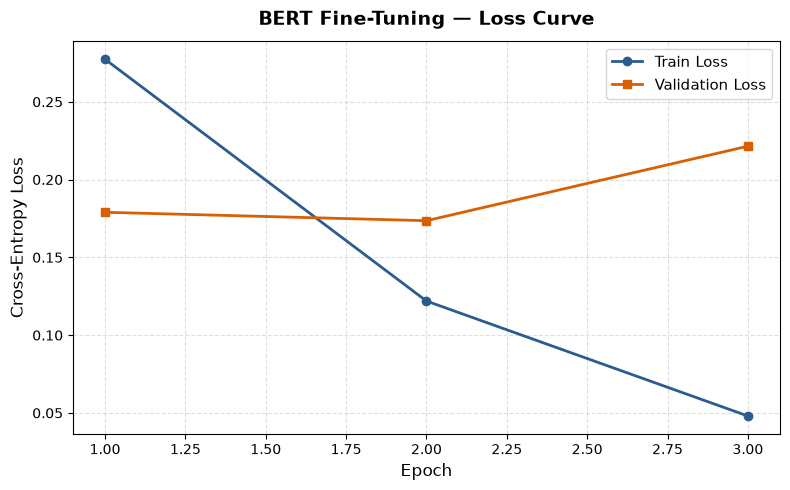

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_x = range(1, EPOCHS + 1)
ax.plot(epochs_x, history["train_loss"], "o-", label="Train Loss",color="#2b5c8f", linewidth=2)
ax.plot(epochs_x, history["val_loss"],   "s-", label="Validation Loss",color="#d95f02", linewidth=2)
ax.set_title("BERT Fine-Tuning — Loss Curve", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.4)
fig.tight_layout()

loss_png = os.path.join(PLOTS_DIR, "bert_loss_curve.png")
fig.savefig(loss_png, dpi=300)
plt.show()

### Save Fine-Tuned Model

In [9]:
save_dir = os.path.join(MODELS_DIR, "bert_fine_tuned")
os.makedirs(save_dir, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Saved fine-tuned model & tokenizer → {save_dir}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.50it/s]

Saved fine-tuned model & tokenizer → .\artifacts\models\bert_fine_tuned


---
## Step 6 (cont.) — Test-Set Evaluation & Verification

In [10]:
model.eval()
y_pred_list, y_true_list = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(ids, attention_mask=mask).logits

        y_pred_list.extend(torch.argmax(logits, 1).cpu().numpy())
        y_true_list.extend(lbls.cpu().numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calculating Metrics
acc = accuracy_score(y_true, y_pred)
p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
p_c, r_c, f1_c, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
cm = confusion_matrix(y_true, y_pred)

print("═" * 50)
print("         BERT — TEST SET RESULTS")
print("═" * 50)
print(f"Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro Precision  : {p_m:.4f}")
print(f"Macro Recall     : {r_m:.4f}")
print(f"Macro F1         : {f1_m:.4f}")
print(f"Class 0 (Neg) F1 : {f1_c[0]:.4f}")
print(f"Class 1 (Pos) F1 : {f1_c[1]:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred,target_names=["Negative", "Positive"], digits=4))

══════════════════════════════════════════════════
         BERT — TEST SET RESULTS
══════════════════════════════════════════════════
Accuracy         : 0.9416  (94.16%)
Macro Precision  : 0.9417
Macro Recall     : 0.9415
Macro F1         : 0.9416
Class 0 (Neg) F1 : 0.9409
Class 1 (Pos) F1 : 0.9422

Full Classification Report:
              precision    recall  f1-score   support

    Negative     0.9483    0.9337    0.9409     12360
    Positive     0.9351    0.9494    0.9422     12439

    accuracy                         0.9416     24799
   macro avg     0.9417    0.9415    0.9416     24799
weighted avg     0.9417    0.9416    0.9416     24799



### Confusion Matrix

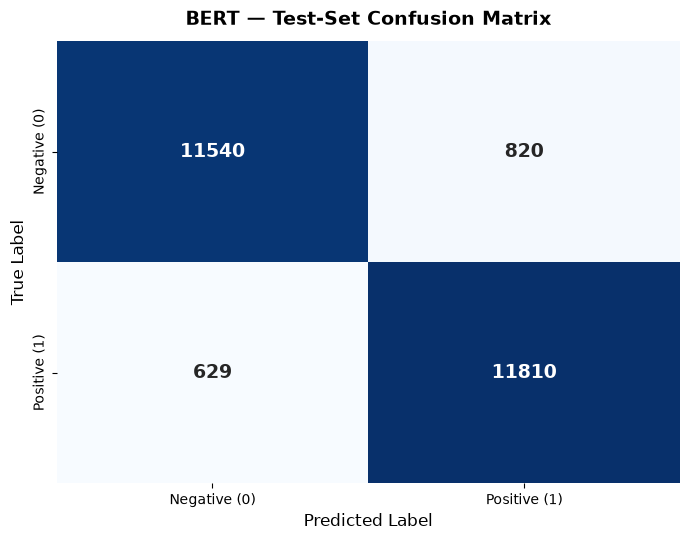

Saved → .\artifacts\plots\bert_confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
ax.set_title("BERT — Test-Set Confusion Matrix",fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
fig.tight_layout()

cm_png = os.path.join(PLOTS_DIR, "bert_confusion_matrix.png")
fig.savefig(cm_png, dpi=300)
plt.show()
print(f"Saved → {cm_png}")

---
## Step 7 — Export Metrics CSV

In [12]:
metrics_df = pd.DataFrame({
    "Model":             ["BERT (bert-base-uncased)"],
    "Accuracy":          [round(acc, 4)],
    "Precision_Macro":   [round(p_m, 4)],
    "Recall_Macro":      [round(r_m, 4)],
    "F1_Macro":          [round(f1_m, 4)],
    "F1_Class0_Neg":     [round(f1_c[0], 4)],
    "F1_Class1_Pos":     [round(f1_c[1], 4)],
    "Training_Time_Sec": [round(total_wall_time, 1)],
})

csv_path = os.path.join(METRICS_DIR, "bert_metrics.csv")
metrics_df.to_csv(csv_path, index=False)
print(f"Saved metrics → {csv_path}\n")
metrics_df

Saved metrics → .\artifacts\metrics\bert_metrics.csv



,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Class0_Neg,F1_Class1_Pos,Training_Time_Sec
0,BERT (bert-base-uncased),0.9416,0.9417,0.9415,0.9416,0.9409,0.9422,1497.3
